
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Partimos de la ecuación de Scrodinger independiente del tiempo:

$$-\frac{\hbar^2}{2m} \nabla^2 \psi(r) + U(r)\psi(r) = E \psi(r)$$

Para el átomo de hidrógeno, el electrón siente la atracción electrostática del protón:

$$ U (r) = -\frac{e^2}{4\pi\epsilon_0r}$$

Por tanto,

$$-\frac{\hbar^2}{2m}\nabla^2\psi-\frac{e^2}{4\pi\epsilon_0r}\psi=E\psi$$

El potencial solamente depende de r, no de $\theta$ ni de $\phi$. Por eso el problema tiene simetría esférica y podemos separar la función de onda:

$$\psi(r,\theta,\phi) = R(r)Y_l^{m}(\theta,\phi)$$

La ecuación para $R(r)$ contiene una derivada segunda y tambien un término con $\frac{2}{r}$. Para hacer el problema mucho más sencillo se define

$$u(r)=rR(r)$$

Con esta transformación, la ecuación radial queda

$$-\frac{\hbar^2}{2m}\frac{d^2u}{dr^2}+\left[\frac{\hbar^2l(l+1)}{2mr^2}-\frac{e^2}{4\pi\epsilon_0r}\right]u=Eu$$

Esta es la ecuación que queremos resolver numéricamente.

Para $l=0$ y unidades atómicas $(\hbar=1, m_e=1, \frac{e^2}{4\pi\epsilon_0}=1)$ tenemos:

$$-\frac{1}{2}\frac{d^2u}{dr^2}-\frac{1}{r}u = Eu$$



**FDM**

Creamos una malla: 
$$r_1,r_2,r_3,...,r_N$$

Con separación $\Delta r=dr$. Para aproximar la segunda derivada utilizamos 
$$\frac{d^2u}{dr^2} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{(\Delta r)^2}$$

Entonces:
$$-\frac{1}{2} \frac{u_{i+1} - 2u_i + u_{i-1}}{(\Delta r)^2} - \frac{1}{r_i}u_i = E u_i$$

Distribuyendo:
$$-\frac{1}{2(\Delta r)^2}u_{i+1} + \frac{1}{(\Delta r)^2}u_i - \frac{1}{2(\Delta r)^2}u_{i-1} - \frac{1}{r_i}u_i = E u_i.$$

Agrupamos los términos:
$$-\frac{1}{2(\Delta r)^2}u_{i-1} + \left[ \frac{1}{(\Delta r)^2} - \frac{1}{r_i} \right] u_i - \frac{1}{2(\Delta r)^2}u_{i+1} = E u_i.$$

Para la diagonal principal 
$$H_{ii}=\frac{1}{dr^2}-\frac{1}{r_i}$$

Para las diagonales secundarias

$$H_{i,i+1}=H_{i,i-1}=-\frac{1}{2dr^2}$$

Por tanto la matriz tiene esta forma: 
$$
H = \begin{pmatrix}
\frac{1}{dr^2} - \frac{1}{r_1} & -\frac{1}{2dr^2} & 0 & \cdots \\
-\frac{1}{2dr^2} & \frac{1}{dr^2} - \frac{1}{r_2} & -\frac{1}{2dr^2} & \cdots \\
0 & -\frac{1}{2dr^2} & \frac{1}{dr^2} - \frac{1}{r_3} & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix}
$$

Y esto es precisamente una representación por diferencias finitas del Hamiltoniano. 

A continuación se muestra el código:

Primeros niveles de energía
n = 1: E_FDM = -0.499825 Ha, E_exacta = -0.500000 Ha, error = 1.752197e-04
n = 2: E_FDM = -0.124989 Ha, E_exacta = -0.125000 Ha, error = 1.096053e-05
n = 3: E_FDM = -0.055421 Ha, E_exacta = -0.055556 Ha, error = 1.340955e-04
n = 4: E_FDM = -0.024638 Ha, E_exacta = -0.031250 Ha, error = 6.612012e-03


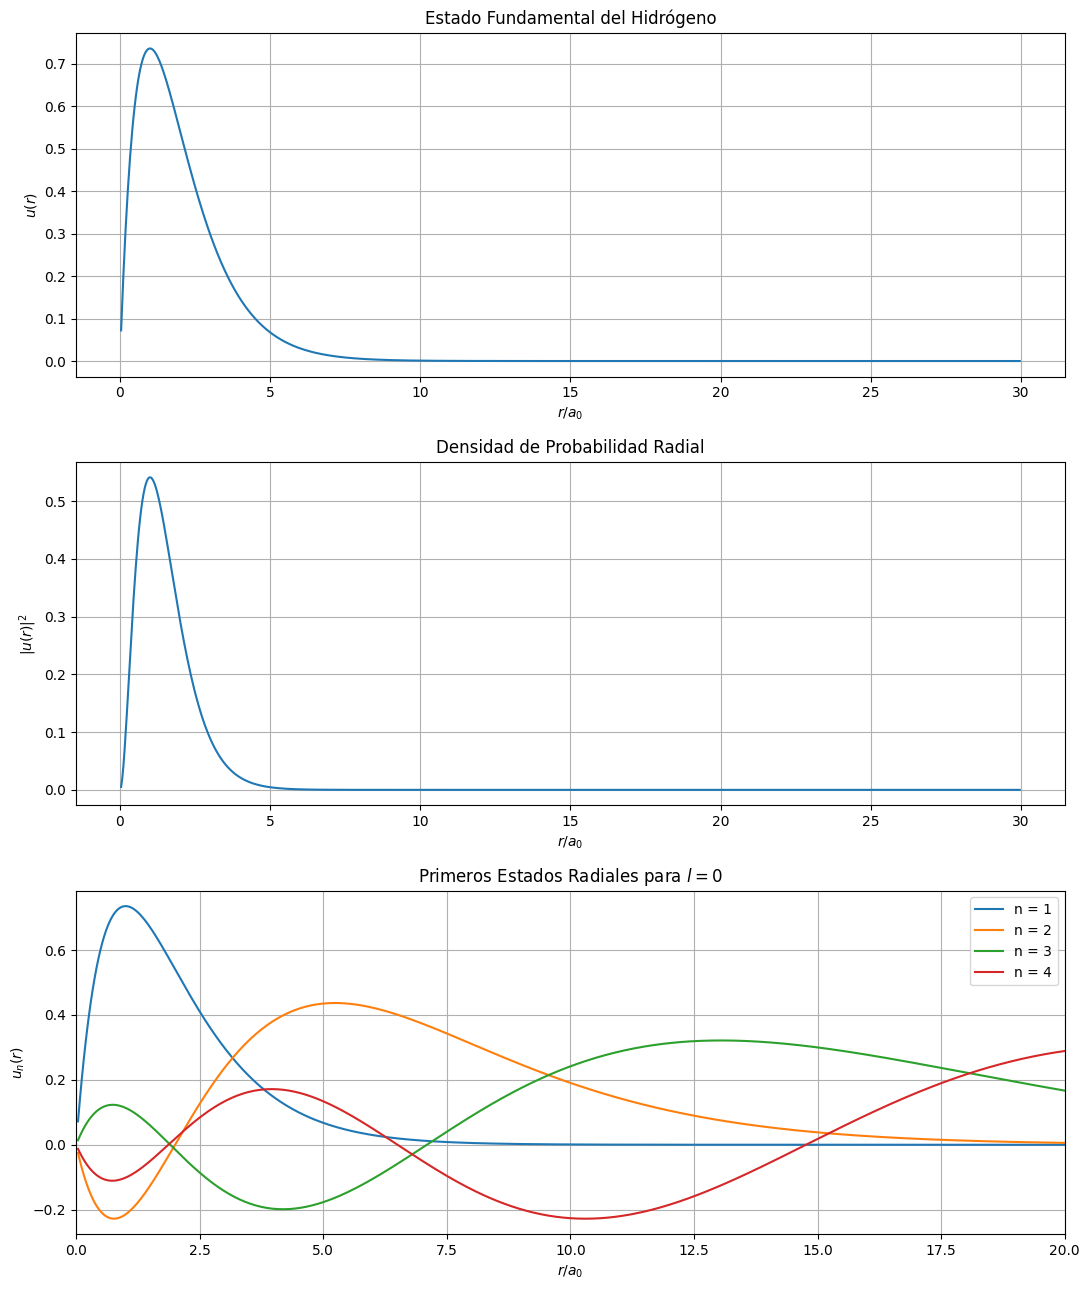

In [11]:
# Creación de la malla

N = 800
r_max = 30.0 #medida en radios de Bohr
dr = r_max / (N + 1) #separación entre puntos
r = np.arange(1, N + 1) * dr #puntos interiores y no se incluye r=0 porque el potencial diverge allí


# Diagonal principal de la matriz
diagonal = 1.0 / dr**2 - 1.0 / r

# Diagonales secundarias
off_diagonal = -0.5 / dr**2 * np.ones(N - 1)

# Construimos la matriz Hamiltoniana
H = np.diag(diagonal)
H += np.diag(off_diagonal, 1)
H += np.diag(off_diagonal, -1)

# Diagonalización
energias, estados = np.linalg.eigh(H)

# Vamos a trabajar con los primeros 4 niveles
numero_niveles = 4
for n in range(numero_niveles):
    estado = estados[:, n]
    norma = np.sqrt(np.sum(estado**2) * dr)
    # Normalizamos
    estados[:, n] = estado / norma

print("Primeros niveles de energía")

for n in range(numero_niveles):
    E_fdm = energias[n]
    # Energía exacta del hidrógeno
    E_exacta = -1.0 / (2.0 * (n + 1)**2)
    error = abs(E_fdm - E_exacta)

    print(
        f"n = {n + 1}: "
        f"E_FDM = {E_fdm:.6f} Ha, "
        f"E_exacta = {E_exacta:.6f} Ha, "
        f"error = {error:.6e}"
    )


# Estado fundamental

u_1 = estados[:, 0] #primer vector propio

# El signo global de un autovector es arbitrario, asi que elegimos la convención u_1 > 0 en su máximo:
if u_1[np.argmax(np.abs(u_1))] < 0:
    u_1 = -u_1

R_1 = u_1 / r #Función radial R(r)
P_1 = np.abs(u_1)**2 #Probabilidad

# Gráficas
fig, axs = plt.subplots(3, 1, figsize=(11, 13))

# Estado fundamental
axs[0].plot(r, u_1)
axs[0].set_xlabel(r"$r/a_0$")
axs[0].set_ylabel(r"$u(r)$")
axs[0].set_title("Estado Fundamental del Hidrógeno")
axs[0].grid()

# Probabilidad
axs[1].plot(r, P_1)
axs[1].set_xlabel(r"$r/a_0$")
axs[1].set_ylabel(r"$|u(r)|^2$")
axs[1].set_title("Densidad de Probabilidad Radial")
axs[1].grid()

#Primeros estados para l=0
for n in range(numero_niveles):
    u = estados[:, n]
    # El signo global de un autovector es arbitrario, lo hacemos positivo para visualizarlo de forma convencional.
    if u[np.argmax(np.abs(u))] < 0:
        u = -u
    axs[2].plot(r,u,label=f"n = {n + 1}")
axs[2].set_xlabel(r"$r/a_0$")
axs[2].set_ylabel(r"$u_n(r)$")
axs[2].set_title("Primeros Estados Radiales para $l=0$")
axs[2].set_xlim(0, 20)
axs[2].grid()
axs[2].legend()

plt.tight_layout()
plt.show()